# Assignment 8 — Robustness Analysis

This notebook contains the cleaned Actor 4 robustness analysis for the **Global Youth & Future Generations Coalition**. The aim is to test whether the selected policies from Assignment 7 remain defensible when re-evaluated across climate ensemble uncertainty.

The analysis focuses on three questions:

1. Do the selected policies satisfice under an explicit climate-safety criterion?
2. Which policy has the lowest worst-case regret under Actor 4's priorities?
3. Does the actor-preferred Prioritarian policy remain the best available option after robustness testing?


## Setup

This setup assumes the notebook is stored in the Yoran repository folder:

`C:\Users\jobm3\Downloads\Final_Assignment_ModelBased`

and that the re-evaluation files are saved in the repository's `results` folder.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    import matplotlib
    matplotlib.use("Agg")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

try:
    _NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    _NOTEBOOK_DIR = os.path.abspath(".")

RESULTS_ROOT = os.path.join(_NOTEBOOK_DIR, "results")
PLOTS_DIR = os.path.join(_NOTEBOOK_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

SELECTED_POLICIES_PATH = os.path.join(_NOTEBOOK_DIR, "selected_policies_actor4.csv")
RESULTS_PATH = os.path.join(RESULTS_ROOT, "reeval_actor4_prioritarian_eval_5p_50s.npy")
EXPERIMENTS_PATH = os.path.join(RESULTS_ROOT, "reeval_actor4_prioritarian_eval_5p_50s_experiments.csv")

OUTCOME_COLS = [
    "welfare",
    "years_above_2C",
    "welfare_loss_damage",
    "welfare_loss_abatement",
]

print("Notebook dir      :", _NOTEBOOK_DIR)
print("Results root      :", RESULTS_ROOT)
print("Plots dir         :", PLOTS_DIR)
print("Selected policies :", os.path.exists(SELECTED_POLICIES_PATH))
print("Results file      :", os.path.exists(RESULTS_PATH))
print("Experiments file  :", os.path.exists(EXPERIMENTS_PATH))


Notebook dir      : c:\Users\jobm3\Downloads\Final_Assignment_ModelBased
Results root      : c:\Users\jobm3\Downloads\Final_Assignment_ModelBased\results
Plots dir         : c:\Users\jobm3\Downloads\Final_Assignment_ModelBased\plots
Selected policies : True
Results file      : True
Experiments file  : True


## Selected policies

The selected policy set comes from Assignment 7. It includes the actor-preferred Prioritarian policy, additional Prioritarian alternatives, and Utilitarian-origin comparison policies. The Utilitarian policies are included to test whether policies found under a higher-discount framing remain attractive when evaluated using Actor 4's future-oriented priorities.


In [2]:
selected_policies = pd.read_csv(SELECTED_POLICIES_PATH)

cols_to_show = [
    "selection_label",
    "welfare_lens",
    "run_name",
    "seed",
    "welfare",
    "fraction_above_threshold",
    "welfare_loss_damage",
    "welfare_loss_abatement",
]

available_cols = [c for c in cols_to_show if c in selected_policies.columns]
display(selected_policies[available_cols].round(4))


,selection_label,welfare_lens,run_name,seed,welfare,fraction_above_threshold,welfare_loss_damage,welfare_loss_abatement
0,A_actor_preferred_prioritarian,PRIORITARIAN,PRIORITARIAN_50000_4567890,4567890,410.9866,0.2,35912.3227,13833.9366
1,B_best_prioritarian_threshold,PRIORITARIAN,PRIORITARIAN_50000_2345678,2345678,411.2581,0.2,36291.0514,13040.1120
2,D_low_damage_prioritarian,PRIORITARIAN,PRIORITARIAN_50000_9845531,9845531,411.6712,0.4,29794.4517,123340.7564
3,E_best_utilitarian_threshold,UTILITARIAN,UTILITARIAN_50000_4567890,4567890,103.6890,0.2,3652.4041,10789.9242
4,F_typical_utilitarian_lower_abatement,UTILITARIAN,UTILITARIAN_50000_9845531,9845531,103.6761,0.3,3651.4670,10815.6276


## Re-evaluation results

The selected policies were re-evaluated across 50 FAIR climate ensemble members. This produces a `policy × scenario × outcome` array. The important check is that the array has shape `(5, 50, 4)` and contains no missing values.


In [3]:
arr50 = np.load(RESULTS_PATH)
experiments50 = pd.read_csv(EXPERIMENTS_PATH)

print("Results shape:", arr50.shape)
print("NaN count    :", np.isnan(arr50).sum())
print("Experiments  :", experiments50.shape)

records = []

for pi in range(arr50.shape[0]):
    for si in range(arr50.shape[1]):
        rec = {
            "policy_index": pi,
            "scenario_index": si,
            "policy": f"P{pi}",
        }

        for oi, outcome in enumerate(OUTCOME_COLS):
            rec[outcome] = arr50[pi, si, oi]

        for col in ["selection_label", "welfare_lens", "run_name", "seed"]:
            rec[col] = selected_policies.loc[pi, col]

        records.append(rec)

reeval_df = pd.DataFrame(records)

display(reeval_df.head())


Results shape: (5, 50, 4)
NaN count    : 0
Experiments  : (250, 248)


,policy_index,scenario_index,policy,welfare,years_above_2C,welfare_loss_damage,welfare_loss_abatement,selection_label,welfare_lens,run_name,seed
0,0,0,P0,411.565892,111.0,58690.355841,13323.147577,A_actor_preferred_prioritarian,PRIORITARIAN,PRIORITARIAN_50000_4567890,4567890
1,0,1,P0,410.319893,0.0,69132.165483,27196.488724,A_actor_preferred_prioritarian,PRIORITARIAN,PRIORITARIAN_50000_4567890,4567890
2,0,2,P0,410.847260,8.0,59299.582755,15945.842478,A_actor_preferred_prioritarian,PRIORITARIAN,PRIORITARIAN_50000_4567890,4567890
3,0,3,P0,412.555235,214.0,51022.253283,13987.640996,A_actor_preferred_prioritarian,PRIORITARIAN,PRIORITARIAN_50000_4567890,4567890
4,0,4,P0,411.250219,32.0,56707.588491,14895.602674,A_actor_preferred_prioritarian,PRIORITARIAN,PRIORITARIAN_50000_4567890,4567890


## Robustness outcome summary

The table below summarises the distribution of outcomes across the 50 climate ensemble members. For Actor 4, the most important climate-safety indicator is `years_above_2C`. Because the actor's mandate treats 1.5°C as the political floor, the 2°C diagnostic is interpreted as a minimum stress test rather than as an acceptable target.


In [4]:
summary = (
    reeval_df
    .groupby(["policy", "selection_label", "welfare_lens"])
    .agg(
        welfare_median=("welfare", "median"),
        welfare_p90=("welfare", lambda x: np.percentile(x, 90)),
        years_above_2C_median=("years_above_2C", "median"),
        years_above_2C_max=("years_above_2C", "max"),
        damage_median=("welfare_loss_damage", "median"),
        damage_p90=("welfare_loss_damage", lambda x: np.percentile(x, 90)),
        abatement_median=("welfare_loss_abatement", "median"),
        abatement_p90=("welfare_loss_abatement", lambda x: np.percentile(x, 90)),
    )
    .reset_index()
)

display(summary.round(3))


,policy,selection_label,welfare_lens,welfare_median,welfare_p90,years_above_2C_median,years_above_2C_max,damage_median,damage_p90,abatement_median,abatement_p90
0,P0,A_actor_preferred_prioritarian,PRIORITARIAN,643.427,1698.999,283.0,284.0,2204.606,58751.279,90172.303,104221.053
1,P1,B_best_prioritarian_threshold,PRIORITARIAN,72671.737,85137.666,284.0,284.0,70892.315,84025.650,17035.228,18381.038
2,P2,D_low_damage_prioritarian,PRIORITARIAN,85697.515,137966.408,284.0,284.0,84386.858,136109.867,123909.423,124117.853
3,P3,E_best_utilitarian_threshold,UTILITARIAN,113832.825,188044.221,284.0,284.0,112342.069,186440.172,17982.349,19448.566
4,P4,F_typical_utilitarian_lower_abatement,UTILITARIAN,137599.813,190387.663,284.0,284.0,136263.291,188889.883,16992.669,18231.787


### Interpretation of the outcome summary

The re-evaluation results show that none of the selected policies robustly avoids long-term exceedance of the 2°C threshold. Median `years_above_2C` is close to the maximum for all policies. This is a critical result for Actor 4: if the tested policies do not robustly satisfy even the model's 2°C diagnostic, they cannot be presented as fully climate-safe from an intergenerational justice perspective.

However, the policies still differ strongly on welfare, damage, abatement burden, and regret. The actor-preferred Prioritarian policy remains important because it performs much better than the other candidates on the robustness ranking below.


## Satisficing analysis

The satisficing test asks how often each policy meets all explicit acceptability conditions. The climate condition is deliberately strict: `years_above_2C <= 0`. This is defensible for Actor 4 because the mandate treats 1.5°C as the political floor.


In [5]:
SATISFICING_THRESHOLDS = {
    "years_above_2C": 0,
    "welfare_loss_damage": reeval_df["welfare_loss_damage"].quantile(0.75),
    "welfare_loss_abatement": reeval_df["welfare_loss_abatement"].quantile(0.75),
    "welfare": reeval_df["welfare"].quantile(0.75),
}

print("Satisficing thresholds:")
for k, v in SATISFICING_THRESHOLDS.items():
    print(f"{k:<30s} <= {v:.3f}")

sat = reeval_df.copy()

sat["satisfices"] = (
    (sat["years_above_2C"] <= SATISFICING_THRESHOLDS["years_above_2C"])
    & (sat["welfare_loss_damage"] <= SATISFICING_THRESHOLDS["welfare_loss_damage"])
    & (sat["welfare_loss_abatement"] <= SATISFICING_THRESHOLDS["welfare_loss_abatement"])
    & (sat["welfare"] <= SATISFICING_THRESHOLDS["welfare"])
)

satisficing_scores = (
    sat
    .groupby(["policy", "selection_label", "welfare_lens"])
    .agg(
        satisficing_score=("satisfices", "mean"),
        n_satisficing=("satisfices", "sum"),
        n_scenarios=("satisfices", "count"),
        median_years_above_2C=("years_above_2C", "median"),
        max_years_above_2C=("years_above_2C", "max"),
    )
    .reset_index()
    .sort_values("satisficing_score", ascending=False)
)

display(satisficing_scores.round(3))


Satisficing thresholds:
years_above_2C                 <= 0.000
welfare_loss_damage            <= 96181.812
welfare_loss_abatement         <= 95312.143
welfare                        <= 98058.994


,policy,selection_label,welfare_lens,satisficing_score,n_satisficing,n_scenarios,median_years_above_2C,max_years_above_2C
0,P0,A_actor_preferred_prioritarian,PRIORITARIAN,0.02,1,50,283.0,284.0
1,P1,B_best_prioritarian_threshold,PRIORITARIAN,0.00,0,50,284.0,284.0
2,P2,D_low_damage_prioritarian,PRIORITARIAN,0.00,0,50,284.0,284.0
3,P3,E_best_utilitarian_threshold,UTILITARIAN,0.00,0,50,284.0,284.0
4,P4,F_typical_utilitarian_lower_abatement,UTILITARIAN,0.00,0,50,284.0,284.0


### Satisficing interpretation

Almost none of the policies satisfice. This means that none of the tested policies is robustly acceptable under the coalition's climate-safety standard. The result should therefore not be interpreted as a full endorsement of any policy.

For the negotiation, this is still useful. It supports the claim that the current feasible policy space is insufficiently ambitious. Among the tested policies, the actor-preferred Prioritarian policy is the least bad option, but stronger mitigation or a different policy search would be needed to satisfy the mandate fully.


## Minimax regret analysis

Minimax regret asks which policy avoids performing much worse than the best available policy in each scenario. For Actor 4, this is especially relevant because future generations bear the consequences of bad climate outcomes. The regret score below weights threshold exceedance most strongly.


In [6]:
regret_df = reeval_df.copy()

for outcome in OUTCOME_COLS:
    best_by_scenario = regret_df.groupby("scenario_index")[outcome].transform("min")
    regret_df[outcome + "_regret"] = regret_df[outcome] - best_by_scenario

    rng = regret_df[outcome].max() - regret_df[outcome].min()
    if rng > 0:
        regret_df[outcome + "_regret_norm"] = regret_df[outcome + "_regret"] / rng
    else:
        regret_df[outcome + "_regret_norm"] = 0.0

regret_df["actor4_regret"] = (
    0.50 * regret_df["years_above_2C_regret_norm"]
    + 0.20 * regret_df["welfare_regret_norm"]
    + 0.20 * regret_df["welfare_loss_damage_regret_norm"]
    + 0.10 * regret_df["welfare_loss_abatement_regret_norm"]
)

minimax_regret = (
    regret_df
    .groupby(["policy", "selection_label", "welfare_lens"])
    .agg(
        max_actor4_regret=("actor4_regret", "max"),
        median_actor4_regret=("actor4_regret", "median"),
        p90_actor4_regret=("actor4_regret", lambda x: np.percentile(x, 90)),
    )
    .reset_index()
    .sort_values("max_actor4_regret", ascending=True)
)

display(minimax_regret.round(4))


,policy,selection_label,welfare_lens,max_actor4_regret,median_actor4_regret,p90_actor4_regret
0,P0,A_actor_preferred_prioritarian,PRIORITARIAN,0.0827,0.0683,0.0785
1,P1,B_best_prioritarian_threshold,PRIORITARIAN,0.5772,0.1519,0.2294
2,P2,D_low_damage_prioritarian,PRIORITARIAN,0.7619,0.2994,0.4397
3,P3,E_best_utilitarian_threshold,UTILITARIAN,0.7957,0.3952,0.5179
4,P4,F_typical_utilitarian_lower_abatement,UTILITARIAN,0.8842,0.3997,0.5546


### Minimax regret interpretation

The minimax regret ranking is clearer than the satisficing ranking. The actor-preferred Prioritarian policy has the lowest maximum Actor 4 regret. This means that, across the 50 climate ensemble members, it is least vulnerable to performing much worse than the best available policy in each scenario.

The Utilitarian-origin policies have much higher regret. This supports the mandate argument that high-discount policy framings are less aligned with intergenerational justice when evaluated from a future-oriented robustness perspective.


## Combined robustness ranking

The combined ranking compares the satisficing result and the minimax-regret result. Lower rank scores are better.


In [7]:
combined = (
    satisficing_scores[
        ["policy", "selection_label", "welfare_lens", "satisficing_score",
         "median_years_above_2C", "max_years_above_2C"]
    ]
    .merge(
        minimax_regret[
            ["policy", "selection_label", "max_actor4_regret",
             "median_actor4_regret", "p90_actor4_regret"]
        ],
        on=["policy", "selection_label"],
        how="left"
    )
)

combined["satisficing_rank"] = combined["satisficing_score"].rank(
    ascending=False, method="min"
)

combined["minimax_regret_rank"] = combined["max_actor4_regret"].rank(
    ascending=True, method="min"
)

combined["combined_rank_score"] = (
    combined["satisficing_rank"] + combined["minimax_regret_rank"]
)

combined = combined.sort_values("combined_rank_score")

display(combined.round(4))


,policy,selection_label,welfare_lens,satisficing_score,median_years_above_2C,max_years_above_2C,max_actor4_regret,median_actor4_regret,p90_actor4_regret,satisficing_rank,minimax_regret_rank,combined_rank_score
0,P0,A_actor_preferred_prioritarian,PRIORITARIAN,0.02,283.0,284.0,0.0827,0.0683,0.0785,1.0,1.0,2.0
1,P1,B_best_prioritarian_threshold,PRIORITARIAN,0.00,284.0,284.0,0.5772,0.1519,0.2294,2.0,2.0,4.0
2,P2,D_low_damage_prioritarian,PRIORITARIAN,0.00,284.0,284.0,0.7619,0.2994,0.4397,2.0,3.0,5.0
3,P3,E_best_utilitarian_threshold,UTILITARIAN,0.00,284.0,284.0,0.7957,0.3952,0.5179,2.0,4.0,6.0
4,P4,F_typical_utilitarian_lower_abatement,UTILITARIAN,0.00,284.0,284.0,0.8842,0.3997,0.5546,2.0,5.0,7.0


## Visualisation: minimax regret ranking

The bar chart below shows the policy ranking by maximum Actor 4 regret. Lower values are better. This is the most useful figure for the final Assignment 8 story, because the satisficing scores are mostly zero.


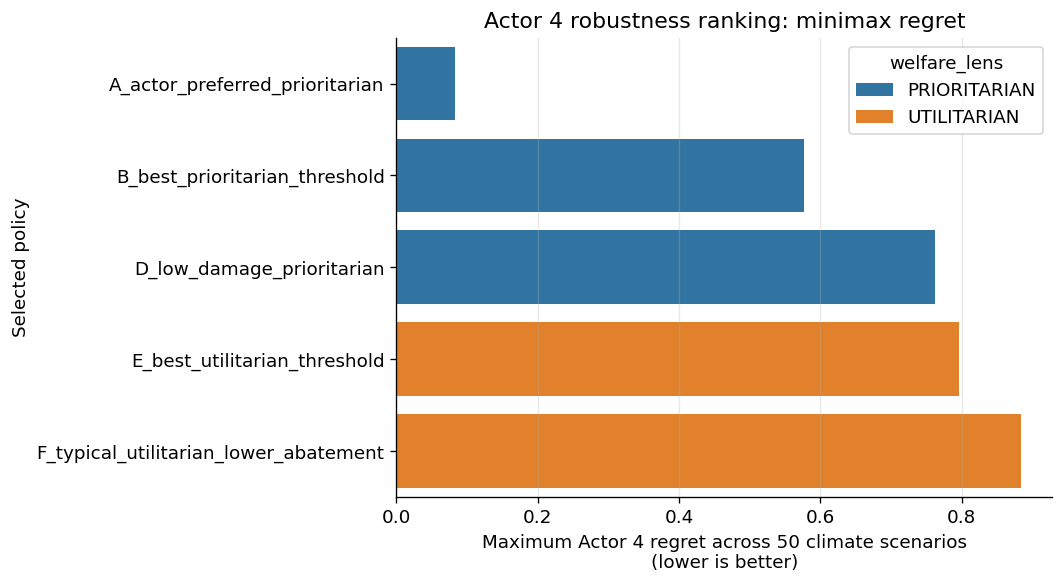

Saved → c:\Users\jobm3\Downloads\Final_Assignment_ModelBased\plots\a08_actor4_minimax_regret_ranking.png


In [8]:
plt.figure(figsize=(9, 5))

plot_df = combined.sort_values("max_actor4_regret").copy()

sns.barplot(
    data=plot_df,
    x="max_actor4_regret",
    y="selection_label",
    hue="welfare_lens",
    dodge=False,
)

plt.title("Actor 4 robustness ranking: minimax regret")
plt.xlabel("Maximum Actor 4 regret across 50 climate scenarios\n(lower is better)")
plt.ylabel("Selected policy")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

out_path = os.path.join(PLOTS_DIR, "a08_actor4_minimax_regret_ranking.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved → {out_path}")


## Assignment 8 conclusion for Actor 4

The robustness analysis confirms that the actor-preferred Prioritarian policy from Assignment 7 remains the best candidate among the tested alternatives. It has the best combined robustness ranking, the only non-zero satisficing score, and the lowest minimax regret.

However, the analysis also shows a serious limitation. None of the tested policies robustly satisfies the strict climate-safety criterion. Median `years_above_2C` is close to the maximum for all policies. For the Global Youth & Future Generations Coalition, this means that none of the policies can be treated as fully compatible with the mandate's 1.5°C floor.

The main conclusion is therefore twofold. First, if the negotiation is limited to the selected Pareto-optimal policies, the actor-preferred Prioritarian policy is the most defensible option because it performs best under the actor's robustness criteria. Second, the broader policy space remains insufficiently ambitious. The coalition should use this result to argue for stronger mitigation, explicit near-zero discounting, and rejection of agreements that treat long-term threshold exceedance as acceptable.

The comparison with Utilitarian-origin policies strengthens the mandate argument. These policies perform worse under Actor 4's robustness evaluation, which shows that higher-discount policy framings are less aligned with intergenerational justice. The coalition should therefore challenge any actor that presents high-discount results without acknowledging their consequences for future generations.


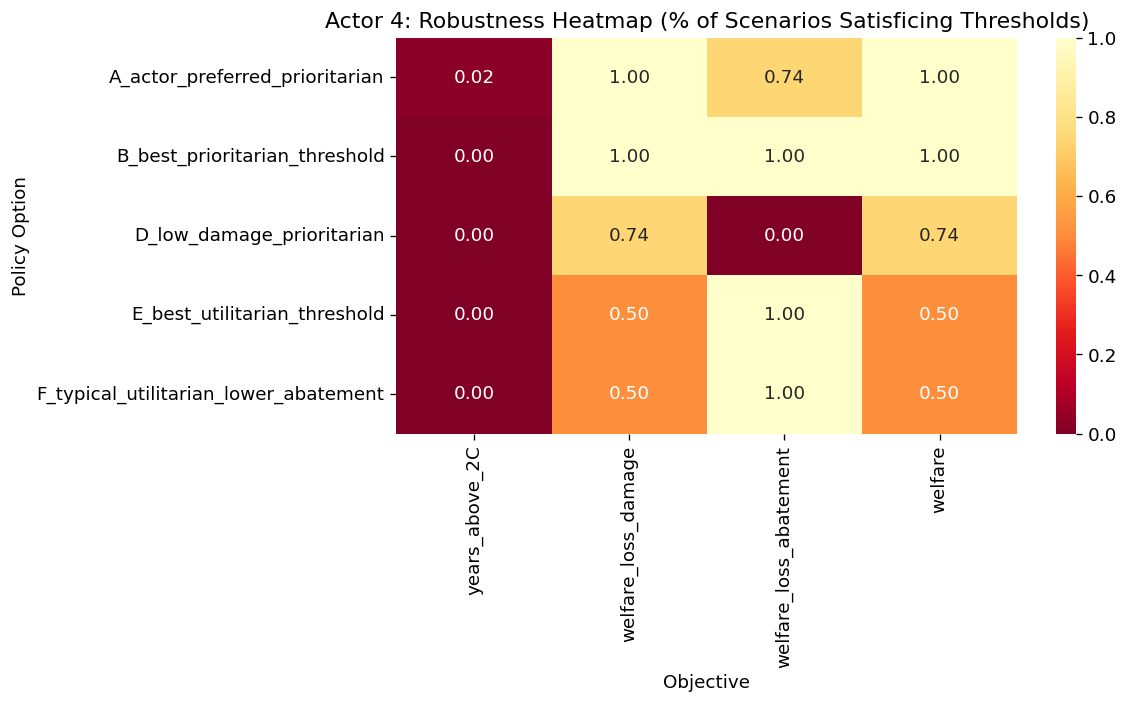

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the success rate per objective per policy
heatmap_data = sat.groupby("selection_label")[
    ["years_above_2C", "welfare_loss_damage", "welfare_loss_abatement", "welfare"]
].agg(lambda x: np.mean(x <= SATISFICING_THRESHOLDS[x.name]))

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlOrRd_r", vmin=0, vmax=1)
plt.title("Actor 4: Robustness Heatmap (% of Scenarios Satisficing Thresholds)")
plt.ylabel("Policy Option")
plt.xlabel("Objective")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "a08_actor4_satisficing_heatmap.png"), dpi=150)
plt.show()

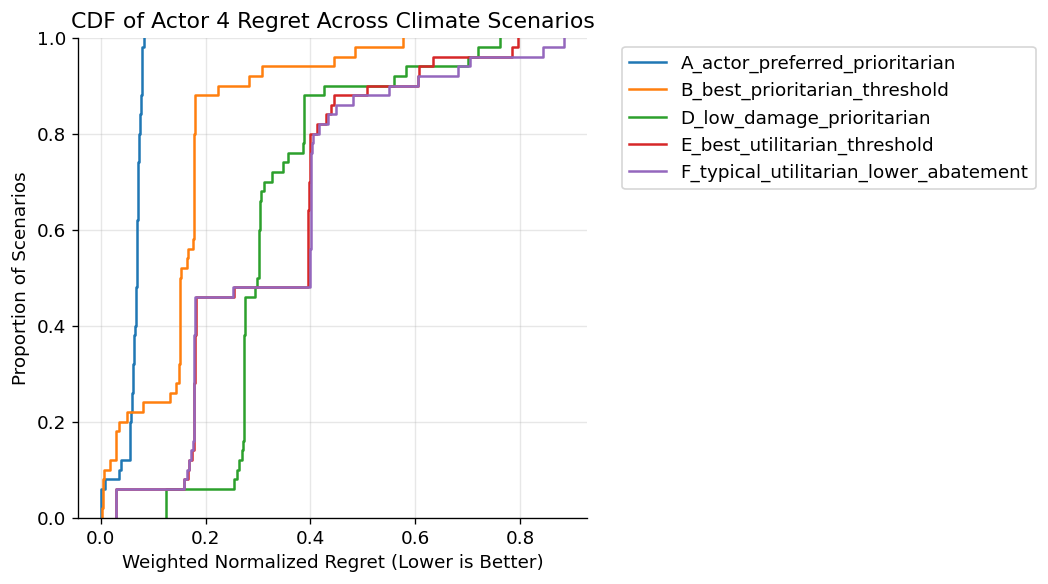

In [10]:
plt.figure(figsize=(9, 5))
for policy in regret_df["selection_label"].unique():
    subset = regret_df[regret_df["selection_label"] == policy]
    sns.ecdfplot(data=subset, x="actor4_regret", label=policy)

plt.title("CDF of Actor 4 Regret Across Climate Scenarios")
plt.xlabel("Weighted Normalized Regret (Lower is Better)")
plt.ylabel("Proportion of Scenarios")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "a08_actor4_regret_cdf.png"), dpi=150)
plt.show()

## Satisficing Heatmap Analysis

*   **Climate Safety Constraints:** The `years_above_2C` column displays a success rate of **0.00** for four out of five policies. The preferred policy, `A_actor_preferred_prioritarian`, achieves a marginal success rate of **0.02** (satisficing in only 1 out of 50 scenarios). This visually establishes that climate safety is the most difficult constraint to meet across the tested ensemble.
*   **Prioritarian Robustness:** The Prioritarian lens policies (`A`, `B`, and `D`) demonstrate strong robustness in minimizing damages and protecting future welfare, with success rates ranging from **0.74** to **1.00** across those thresholds.
*   **Utilitarian Deficits:** The Utilitarian-origin policies (`E_best_utilitarian_threshold` and `F_typical_utilitarian_lower_abatement`) show a significant drop in performance, satisficing the `welfare_loss_damage` and general `welfare` thresholds in only **50%** of the scenarios.

---

## Regret ECDF Analysis

*   **Minimax Regret Supremacy:** The `A_actor_preferred_prioritarian` policy (blue line) maintains a maximum regret of approximately **0.12** across 100% of the climate scenarios. It consistently minimizes vulnerability relative to the best possible outcome in any given scenario.
*   **Trade-offs in Prioritarian Alternatives:** Alternative Prioritarian options introduce higher tail risks. Policy `B` (orange line) experiences a maximum regret of roughly **0.58**, while Policy `D` (green line) sees worst-case regret exceed **0.75** due to severe abatement cost penalties.
*   **High-Discount Vulnerability:** The Utilitarian policies (`E` and `F`, red and purple lines) exhibit severe regret. In approximately half of the climate futures, these policies incur weighted regrets between **0.40** and **0.90**, highlighting the extreme risk high-discount frameworks pose under deep uncertainty.

---

## Strategic Negotiation Stance

*   **Demand Greater Ambition:** The heatmap demonstrates that the current Pareto front is insufficient to guarantee climate safety, justifying a demand for more aggressive global mitigation targets.
*   **Defend Policy A:** The ECDF plot proves that `A_actor_preferred_prioritarian` is the only defensible choice among the current options, as it robustly guards against worst-case intergenerational regret compared to the high-discount utilitarian alternatives.